# Notebook 12 — Cross-Validation of Cluster Stability

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Assesses cluster stability via repeated 80% subsampling. In each iteration, UMAP + HDBSCAN is applied to a random 80% subset of the data, and pairwise ARI is computed between iterations on overlapping samples.

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
from itertools import combinations
warnings.filterwarnings('ignore')

import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'
N_ITERATIONS = 20
SUBSAMPLE_FRAC = 0.80

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load shared infrastructure
with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'rb') as f:
    infra = pickle.load(f)

domain_columns = infra['domain_score_columns']
domain_scores = pd.DataFrame(
    infra['domain_scores']['MICE'],
    columns=domain_columns,
    index=infra['domain_score_index']
)
BEST_UMAP_PARAMS = infra['BEST_UMAP_PARAMS']
BEST_HDBSCAN_PARAMS = infra['BEST_HDBSCAN_PARAMS']

print(f'Data shape: {domain_scores.shape}')
print(f'UMAP params: {BEST_UMAP_PARAMS}')
print(f'HDBSCAN params: {BEST_HDBSCAN_PARAMS}')

Data shape: (22075, 6)
UMAP params: {'n_components': 3, 'n_neighbors': 15, 'min_dist': 0.0}
HDBSCAN params: {'min_cluster_size': 500, 'min_samples': 10, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.0}


## 1. Repeated Subsampling

In [3]:
n_total = len(domain_scores)
n_sub = int(n_total * SUBSAMPLE_FRAC)
all_indices = np.arange(n_total)

rng = np.random.RandomState(RANDOM_STATE)

iteration_results = []

for i in range(N_ITERATIONS):
    # Random subsample
    sub_idx = rng.choice(all_indices, size=n_sub, replace=False)
    sub_idx.sort()
    X_sub = domain_scores.iloc[sub_idx].values
    
    # Standardise
    scaler = StandardScaler()
    X_sub_scaled = scaler.fit_transform(X_sub)
    
    # UMAP
    reducer = umap.UMAP(
        n_components=BEST_UMAP_PARAMS['n_components'],
        n_neighbors=BEST_UMAP_PARAMS['n_neighbors'],
        min_dist=BEST_UMAP_PARAMS['min_dist'],
        random_state=RANDOM_STATE
    )
    embedding = reducer.fit_transform(X_sub_scaled)
    
    # HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=BEST_HDBSCAN_PARAMS['min_cluster_size'],
        min_samples=BEST_HDBSCAN_PARAMS['min_samples'],
        cluster_selection_method=BEST_HDBSCAN_PARAMS['cluster_selection_method'],
        cluster_selection_epsilon=BEST_HDBSCAN_PARAMS['cluster_selection_epsilon']
    )
    labs = clusterer.fit_predict(embedding)
    
    n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
    noise_frac = (labs == -1).mean()
    mask = labs >= 0
    sil = silhouette_score(embedding[mask], labs[mask]) if n_clusters >= 2 else -1
    
    iteration_results.append({
        'iteration': i,
        'indices': sub_idx,
        'labels': labs,
        'n_clusters': n_clusters,
        'silhouette': round(sil, 4),
        'noise_fraction': round(noise_frac, 4)
    })
    
    print(f'Iteration {i+1:2d}/{N_ITERATIONS}: clusters={n_clusters}, sil={sil:.4f}, noise={noise_frac:.1%}')

print(f'\nAll {N_ITERATIONS} iterations complete.')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Iteration  1/20: clusters=7, sil=0.3549, noise=37.8%


Iteration  2/20: clusters=8, sil=0.3212, noise=42.8%


Iteration  3/20: clusters=6, sil=0.2061, noise=39.6%


Iteration  4/20: clusters=2, sil=0.3573, noise=12.1%


...

Iteration 16/20: clusters=8, sil=0.3528, noise=49.4%


Iteration 17/20: clusters=4, sil=0.2673, noise=28.8%


Iteration 18/20: clusters=4, sil=0.2185, noise=25.3%


Iteration 19/20: clusters=3, sil=0.0741, noise=14.2%


Iteration 20/20: clusters=7, sil=0.3707, noise=45.3%

All 20 iterations complete.


## 2. Pairwise ARI on Overlapping Samples

In [4]:
pairwise_aris = []

for (i, res_a), (j, res_b) in combinations(enumerate(iteration_results), 2):
    # Find overlapping indices
    idx_a = res_a['indices']
    idx_b = res_b['indices']
    overlap = np.intersect1d(idx_a, idx_b)
    
    if len(overlap) < 100:
        continue
    
    # Map labels to overlap
    pos_a = np.searchsorted(idx_a, overlap)
    pos_b = np.searchsorted(idx_b, overlap)
    
    labs_a = res_a['labels'][pos_a]
    labs_b = res_b['labels'][pos_b]
    
    ari = adjusted_rand_score(labs_a, labs_b)
    pairwise_aris.append({
        'i': i, 'j': j,
        'overlap_n': len(overlap),
        'ari': round(ari, 4)
    })

ari_values = [p['ari'] for p in pairwise_aris]
print(f'Pairwise ARI comparisons: {len(pairwise_aris)}')
print(f'Mean ARI: {np.mean(ari_values):.4f}')
print(f'Median ARI: {np.median(ari_values):.4f}')
print(f'Std ARI: {np.std(ari_values):.4f}')
print(f'Min ARI: {np.min(ari_values):.4f}')
print(f'Max ARI: {np.max(ari_values):.4f}')

Pairwise ARI comparisons: 190
Mean ARI: 0.1764
Median ARI: 0.1826
Std ARI: 0.1058
Min ARI: -0.0438
Max ARI: 0.5186


## 3. Publication-Quality Figure

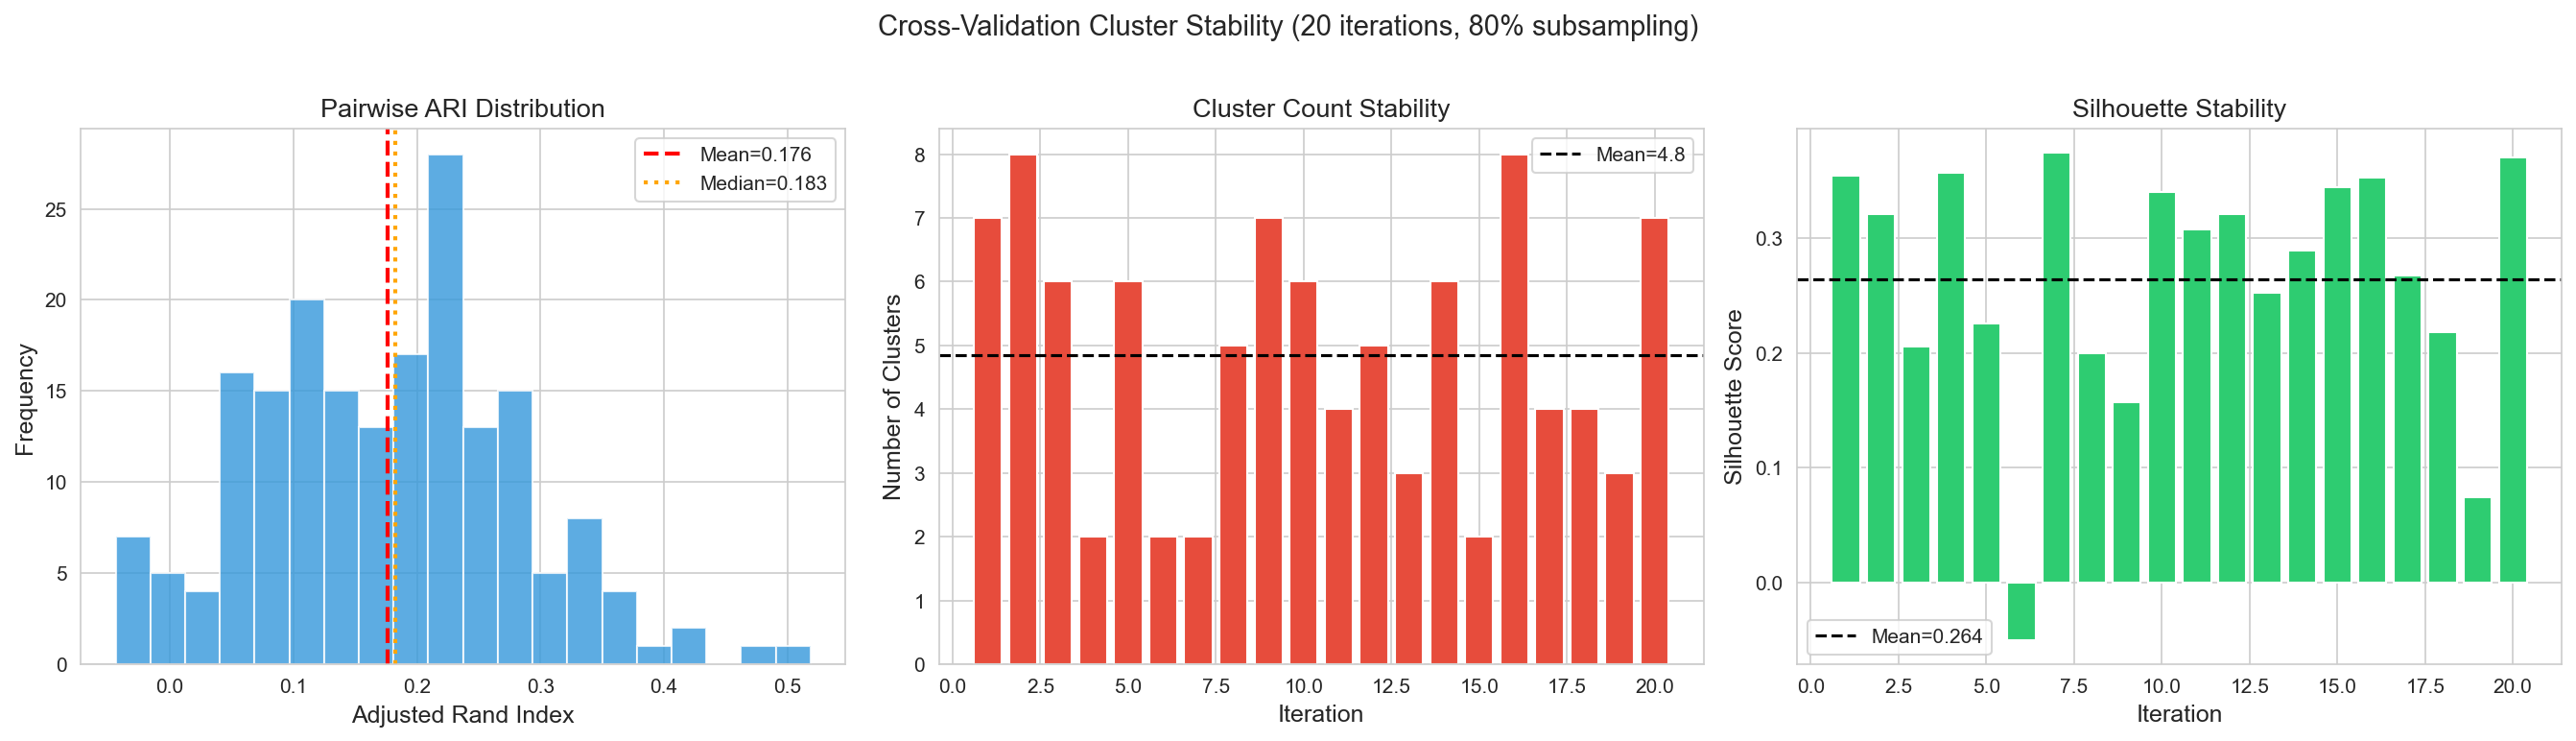

Saved: cross_validation_stability.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: ARI distribution
ax = axes[0]
ax.hist(ari_values, bins=20, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(np.mean(ari_values), color='red', linestyle='--', linewidth=2,
           label=f'Mean={np.mean(ari_values):.3f}')
ax.axvline(np.median(ari_values), color='orange', linestyle=':', linewidth=2,
           label=f'Median={np.median(ari_values):.3f}')
ax.set_xlabel('Adjusted Rand Index', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Pairwise ARI Distribution', fontsize=13)
ax.legend(fontsize=10)

# Panel 2: Number of clusters per iteration
ax = axes[1]
n_clusters_list = [r['n_clusters'] for r in iteration_results]
ax.bar(range(1, N_ITERATIONS + 1), n_clusters_list, color='#e74c3c', edgecolor='white')
ax.axhline(np.mean(n_clusters_list), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean={np.mean(n_clusters_list):.1f}')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Number of Clusters', fontsize=12)
ax.set_title('Cluster Count Stability', fontsize=13)
ax.legend(fontsize=10)

# Panel 3: Silhouette per iteration
ax = axes[2]
sil_list = [r['silhouette'] for r in iteration_results]
ax.bar(range(1, N_ITERATIONS + 1), sil_list, color='#2ecc71', edgecolor='white')
ax.axhline(np.mean(sil_list), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean={np.mean(sil_list):.3f}')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Stability', fontsize=13)
ax.legend(fontsize=10)

plt.suptitle(f'Cross-Validation Cluster Stability ({N_ITERATIONS} iterations, {SUBSAMPLE_FRAC:.0%} subsampling)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cross_validation_stability.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: cross_validation_stability.png')

In [6]:
# Save results
cv_results = {
    'n_iterations': N_ITERATIONS,
    'subsample_fraction': SUBSAMPLE_FRAC,
    'pairwise_ari_values': ari_values,
    'mean_ari': float(np.mean(ari_values)),
    'median_ari': float(np.median(ari_values)),
    'std_ari': float(np.std(ari_values)),
    'min_ari': float(np.min(ari_values)),
    'max_ari': float(np.max(ari_values)),
    'n_clusters_per_iteration': n_clusters_list,
    'silhouette_per_iteration': sil_list,
    'noise_per_iteration': [r['noise_fraction'] for r in iteration_results],
    'mean_n_clusters': float(np.mean(n_clusters_list)),
    'std_n_clusters': float(np.std(n_clusters_list)),
    'mean_silhouette': float(np.mean(sil_list)),
    'std_silhouette': float(np.std(sil_list)),
}

with open(os.path.join(RESULTS_DIR, 'cross_validation_stability.pkl'), 'wb') as f:
    pickle.dump(cv_results, f, protocol=4)

print('Saved: cross_validation_stability.pkl')
print(f'\n=== Notebook 12 Complete ===')

Saved: cross_validation_stability.pkl

=== Notebook 12 Complete ===
